<a href="https://colab.research.google.com/github/Seetal-0903/AI-Driven-Cybersecurity-Threat-Prediction-Platform/blob/main/SQL_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DataFrame API Queries Using PySpark**

In [4]:
!pip install findspark
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Create a SparkSession
sprk = SparkSession.builder.appName("DataFrameAPIExample").getOrCreate()

# Sample data
data = [
    ("Alice", 1, "New York"),
    ("Bob", 2, "Los Angeles"),
    ("Charlie", 1, "New York"),
    ("David", 3, "Chicago"),
    ("Eve", 2, "Los Angeles")
]

# Define schema
columns = ["name", "id", "city"]

# Create a DataFrame
df = sprk.createDataFrame(data, columns)

# Show the schema of the DataFrame
print("DataFrame Schema:")
df.printSchema()

# Show the first few rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
df.show()

# Select specific columns and filter data
print("\nSelecting 'name' and 'city' for id = 1:")
df.select("name", "city").filter(col("id") == 1).show()

# sprk.stop() # Removed to keep the SparkSession active

DataFrame Schema:
root
 |-- name: string (nullable = true)
 |-- id: long (nullable = true)
 |-- city: string (nullable = true)


First 5 rows of the DataFrame:
+-------+---+-----------+
|   name| id|       city|
+-------+---+-----------+
|  Alice|  1|   New York|
|    Bob|  2|Los Angeles|
|Charlie|  1|   New York|
|  David|  3|    Chicago|
|    Eve|  2|Los Angeles|
+-------+---+-----------+


Selecting 'name' and 'city' for id = 1:
+-------+--------+
|   name|    city|
+-------+--------+
|  Alice|New York|
|Charlie|New York|
+-------+--------+



**Spark Sql queries**

In [5]:
from pyspark.sql import SparkSession

# Create a SparkSession (if not already running, though it should be from previous cells)
# Using `getOrCreate()` ensures we use the existing session if one is active
sprk = SparkSession.builder.appName("SparkSQLQueries").getOrCreate()

# Assuming 'df' DataFrame is already defined from previous execution
# Register the DataFrame as a temporary SQL view
df.createOrReplaceTempView("people")

print("\n--- Spark SQL Query 1: Select all from 'people' ---")
sprk.sql("SELECT * FROM people").show()

print("\n--- Spark SQL Query 2: Select names and cities where id = 1 ---")
sprk.sql("SELECT name, city FROM people WHERE id = 1").show()

print("\n--- Spark SQL Query 3: Count people by city ---")
sprk.sql("SELECT city, COUNT(*) as count FROM people GROUP BY city").show()

# No need to stop sprk here if we want to keep it active for further queries
# sprk.stop() # Uncomment if you want to stop the SparkSession after these queries


--- Spark SQL Query 1: Select all from 'people' ---
+-------+---+-----------+
|   name| id|       city|
+-------+---+-----------+
|  Alice|  1|   New York|
|    Bob|  2|Los Angeles|
|Charlie|  1|   New York|
|  David|  3|    Chicago|
|    Eve|  2|Los Angeles|
+-------+---+-----------+


--- Spark SQL Query 2: Select names and cities where id = 1 ---
+-------+--------+
|   name|    city|
+-------+--------+
|  Alice|New York|
|Charlie|New York|
+-------+--------+


--- Spark SQL Query 3: Count people by city ---
+-----------+-----+
|       city|count|
+-----------+-----+
|Los Angeles|    2|
|   New York|    2|
|    Chicago|    1|
+-----------+-----+



**Starting a PySpark Session**

In [6]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

# Create a SparkSession instance
spark = SparkSession.builder.appName("NewSparkSession").getOrCreate()

print("SparkSession created successfully!")
print(f"Application Name: {spark.sparkContext.appName}")
print(f"Spark Master: {spark.sparkContext.master}")

SparkSession created successfully!
Application Name: SparkSQLQueries
Spark Master: local[*]


## Create Sales Data File




In [7]:
import pandas as pd

# Sample data for sales records
sales_data = {
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Webcam', 'Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Webcam'],
    'Region': ['East', 'West', 'North', 'South', 'East', 'West', 'North', 'South', 'East', 'West'],
    'SalesAmount': [1200, 25, 75, 300, 50, 1100, 30, 80, 320, 55]
}

# Create a pandas DataFrame
sales_df = pd.DataFrame(sales_data)

# Save the DataFrame to a CSV file
sales_df.to_csv('sales_data.csv', index=False)

print("sales_data.csv created successfully with the following content:")
print(sales_df.head())

sales_data.csv created successfully with the following content:
    Product Region  SalesAmount
0    Laptop   East         1200
1     Mouse   West           25
2  Keyboard  North           75
3   Monitor  South          300
4    Webcam   East           50


## Load Sales Data



In [8]:
from pyspark.sql import SparkSession

# Get or create a SparkSession
spark = SparkSession.builder.appName("SalesAnalysis").getOrCreate()

# Load the sales_data.csv file into a PySpark DataFrame
sales_pyspark_df = spark.read.csv('sales_data.csv', header=True, inferSchema=True)

# Display the schema of the loaded DataFrame
print("\nPySpark DataFrame Schema:")
sales_pyspark_df.printSchema()

# Show the first few rows of the DataFrame
print("\nFirst 5 rows of the PySpark DataFrame:")
sales_pyspark_df.show(5)


PySpark DataFrame Schema:
root
 |-- Product: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- SalesAmount: integer (nullable = true)


First 5 rows of the PySpark DataFrame:
+--------+------+-----------+
| Product|Region|SalesAmount|
+--------+------+-----------+
|  Laptop|  East|       1200|
|   Mouse|  West|         25|
|Keyboard| North|         75|
| Monitor| South|        300|
|  Webcam|  East|         50|
+--------+------+-----------+
only showing top 5 rows



## Analyze Sales by Product and Region




In [9]:
from pyspark.sql.functions import sum

# Group by 'Product' and 'Region' and calculate the sum of 'SalesAmount'
sales_by_product_region_df = sales_pyspark_df.groupBy("Product", "Region").agg(sum("SalesAmount").alias("TotalSales"))

# Display the aggregated DataFrame
print("\nTotal Sales by Product and Region:")
sales_by_product_region_df.show()


Total Sales by Product and Region:
+--------+------+----------+
| Product|Region|TotalSales|
+--------+------+----------+
|  Laptop|  East|      1200|
|  Webcam|  East|        50|
|Keyboard| North|        75|
| Monitor|  East|       320|
|   Mouse| North|        30|
|Keyboard| South|        80|
|   Mouse|  West|        25|
|  Webcam|  West|        55|
| Monitor| South|       300|
|  Laptop|  West|      1100|
+--------+------+----------+



## Visualize Sales Performance




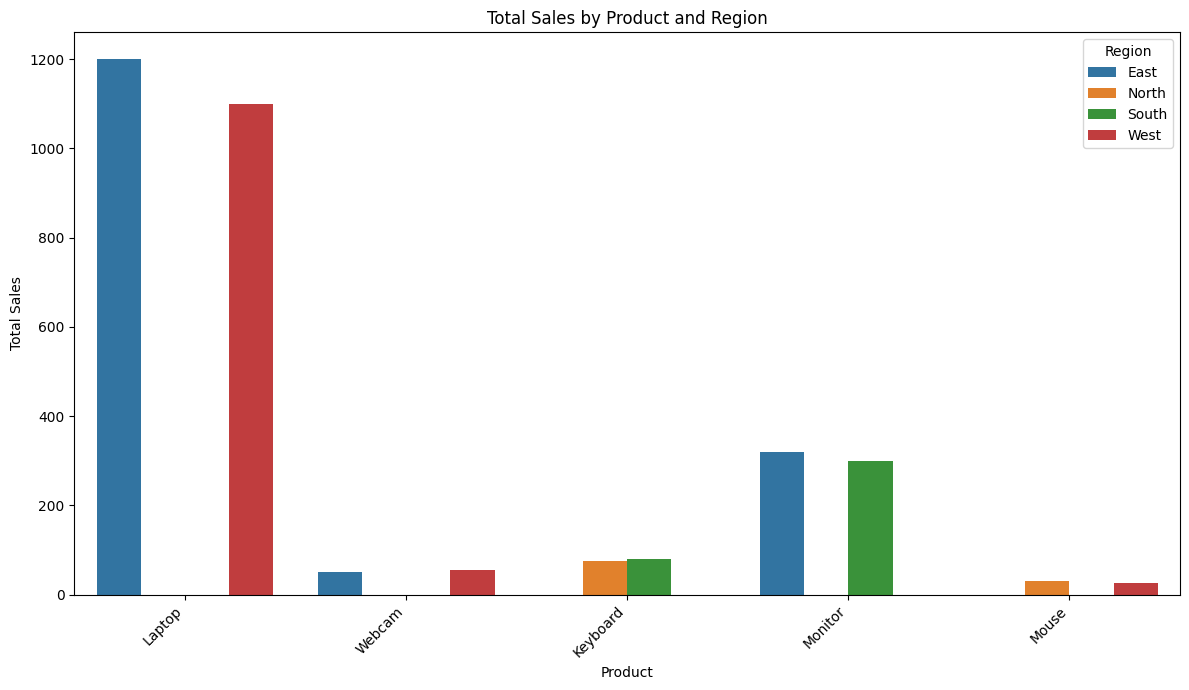

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the PySpark DataFrame to a Pandas DataFrame
sales_pandas_df = sales_by_product_region_df.toPandas()

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Product', y='TotalSales', hue='Region', data=sales_pandas_df)

# Add title and labels
plt.title('Total Sales by Product and Region')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Region')
plt.tight_layout()

# Display the plot
plt.show()

## Summary:

### Data Analysis Key Findings

*   A sample `sales_data.csv` file was successfully generated containing `Product`, `Region`, and `SalesAmount` columns.
*   The data was loaded into a PySpark DataFrame, with `SalesAmount` correctly inferred as an integer type.
*   Total sales were calculated by product and region, revealing specific sales figures:
    *   Laptop sales were \$1200 in East and \$1100 in West.
    *   Monitor sales were \$320 in East and \$300 in South.
    *   Mouse sales were \$30 in North and \$25 in West.
    *   Keyboard sales were \$75 in North and \$80 in South.
    *   Webcam sales were \$50 in East and \$55 in West.
*   The visualization confirmed that "Laptop" is the top-performing product overall, with high sales in both the East (\$1200) and West (\$1100) regions, followed by "Monitor" in the East (\$320) and South (\$300).
*   The "East" and "West" regions appear to be significant contributors to Laptop sales, while "East" also shows strong performance for Monitors.




## Create Sample JSON File




In [11]:
import json

# Sample data for people records with intentional missing values
people_data = [
    {"name": "Alice", "age": 30, "occupation": "Engineer"},
    {"name": "Bob", "age": None, "occupation": "Doctor"},
    {"name": "Charlie", "age": 35, "occupation": None},
    {"name": "David", "age": 28, "occupation": "Artist"},
    {"name": "Eve", "age": 42, "occupation": "Manager"},
    {"name": "Frank", "age": None, "occupation": None}
]

# Define the filename
filename = 'people.json'

# Write the data to a JSON file
with open(filename, 'w') as json_file:
    json.dump(people_data, json_file, indent=4)

print(f"'{filename}' created successfully with the following content:")
with open(filename, 'r') as json_file:
    print(json_file.read())

'people.json' created successfully with the following content:
[
    {
        "name": "Alice",
        "age": 30,
        "occupation": "Engineer"
    },
    {
        "name": "Bob",
        "age": null,
        "occupation": "Doctor"
    },
    {
        "name": "Charlie",
        "age": 35,
        "occupation": null
    },
    {
        "name": "David",
        "age": 28,
        "occupation": "Artist"
    },
    {
        "name": "Eve",
        "age": 42,
        "occupation": "Manager"
    },
    {
        "name": "Frank",
        "age": null,
        "occupation": null
    }
]


## Load JSON Data into DataFrame




In [14]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# Get or create a SparkSession (should be already running)
spark = SparkSession.builder.appName("JSONLoading").getOrCreate()

# Define the schema explicitly
schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("occupation", StringType(), True)
])

# Load the 'people.json' file into a PySpark DataFrame with the specified schema
people_pyspark_df = spark.read.schema(schema).json('people.json')

# Display the schema of the loaded DataFrame
print("\nPySpark DataFrame Schema:")
people_pyspark_df.printSchema()

# Show the first few rows of the DataFrame
print("\nFirst 5 rows of the PySpark DataFrame:")
people_pyspark_df.show(5)


PySpark DataFrame Schema:
root
 |-- age: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- occupation: string (nullable = true)


First 5 rows of the PySpark DataFrame:
+----+----+----------+
| age|name|occupation|
+----+----+----------+
|NULL|NULL|      NULL|
|NULL|NULL|      NULL|
|NULL|NULL|      NULL|
|NULL|NULL|      NULL|
|NULL|NULL|      NULL|
+----+----+----------+
only showing top 5 rows



In [15]:
import json
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# Get or create a SparkSession (should be already running)
spark = SparkSession.builder.appName("JSONLoading").getOrCreate()

# Define the schema explicitly, as it helps with createDataFrame from Python objects
schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("occupation", StringType(), True)
])

# Read the JSON file content as a string
with open('people.json', 'r') as f:
    json_content = f.read()

# Parse the JSON string into a Python list of dictionaries
people_list = json.loads(json_content)

# Create a PySpark DataFrame from the list of dictionaries with the defined schema
people_pyspark_df = spark.createDataFrame(people_list, schema=schema)

# Display the schema of the loaded DataFrame
print("\nPySpark DataFrame Schema:")
people_pyspark_df.printSchema()

# Show the first few rows of the DataFrame
print("\nFirst 5 rows of the PySpark DataFrame:")
people_pyspark_df.show(5)


PySpark DataFrame Schema:
root
 |-- age: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- occupation: string (nullable = true)


First 5 rows of the PySpark DataFrame:
+----+-------+----------+
| age|   name|occupation|
+----+-------+----------+
|  30|  Alice|  Engineer|
|NULL|    Bob|    Doctor|
|  35|Charlie|      NULL|
|  28|  David|    Artist|
|  42|    Eve|   Manager|
+----+-------+----------+
only showing top 5 rows



## Add a New Column



In [16]:
from pyspark.sql.functions import when, col

# Add a new column 'is_adult' based on the 'age' column
people_pyspark_df_with_adult = people_pyspark_df.withColumn(
    "is_adult",
    when(col("age") >= 18, True)
    .when(col("age") < 18, False)
    .otherwise(None) # Handles null ages
)

# Display the schema of the updated DataFrame
print("\nPySpark DataFrame Schema with 'is_adult' column:")
people_pyspark_df_with_adult.printSchema()

# Show the first few rows of the updated DataFrame
print("\nFirst few rows of the DataFrame with 'is_adult' column:")
people_pyspark_df_with_adult.show()


PySpark DataFrame Schema with 'is_adult' column:
root
 |-- age: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- is_adult: boolean (nullable = true)


First few rows of the DataFrame with 'is_adult' column:
+----+-------+----------+--------+
| age|   name|occupation|is_adult|
+----+-------+----------+--------+
|  30|  Alice|  Engineer|    true|
|NULL|    Bob|    Doctor|    NULL|
|  35|Charlie|      NULL|    true|
|  28|  David|    Artist|    true|
|  42|    Eve|   Manager|    true|
|NULL|  Frank|      NULL|    NULL|
+----+-------+----------+--------+



## Handle Missing Values




In [17]:
print("\n--- DataFrame after dropping rows with any null values ---")
df_dropped_na = people_pyspark_df_with_adult.dropna()
df_dropped_na.show()


--- DataFrame after dropping rows with any null values ---
+---+-----+----------+--------+
|age| name|occupation|is_adult|
+---+-----+----------+--------+
| 30|Alice|  Engineer|    true|
| 28|David|    Artist|    true|
| 42|  Eve|   Manager|    true|
+---+-----+----------+--------+



In [18]:
print("\n--- DataFrame after filling null values ---")
df_filled_na = people_pyspark_df_with_adult.fillna({"age": 0, "occupation": "Unknown"})
df_filled_na.show()


--- DataFrame after filling null values ---
+---+-------+----------+--------+
|age|   name|occupation|is_adult|
+---+-------+----------+--------+
| 30|  Alice|  Engineer|    true|
|  0|    Bob|    Doctor|    NULL|
| 35|Charlie|   Unknown|    true|
| 28|  David|    Artist|    true|
| 42|    Eve|   Manager|    true|
|  0|  Frank|   Unknown|    NULL|
+---+-------+----------+--------+



## Summary:

### Data Analysis Key Findings

*   **JSON Data Generation:** A sample `people.json` file was successfully created, containing records with 'name', 'age', and 'occupation'. This file intentionally included `null` values for 'age' and 'occupation' to facilitate subsequent missing data handling demonstrations.
*   **PySpark DataFrame Loading Challenges and Solutions:**
    *   Initial attempts to load the `people.json` file directly using `spark.read.json()` were unsuccessful because the file was structured as a single JSON array rather than line-delimited JSON objects, leading to parsing failures.
    *   The issue was resolved by first reading the JSON content into a Python list of dictionaries and then creating a PySpark DataFrame using `spark.createDataFrame()` with an explicitly defined schema (`age: integer`, `name: string`, `occupation: string`). This method successfully loaded the data, preserving the `null` values.
*   **Data Transformation (Adding a New Column):** A new column named `is_adult` (of boolean type) was successfully added to the DataFrame using `withColumn` and `when().otherwise()` PySpark functions. This column was populated based on the 'age' column: `True` for ages >= 18, `False` for ages < 18, and `NULL` when 'age' was `NULL`.
*   **Missing Value Handling:**
    *   **Dropping Rows:** The `dropna()` PySpark operation effectively removed all rows containing any `NULL` values from the DataFrame. For example, records with missing 'age' or 'occupation' were excluded, leaving only complete entries.
    *   **Filling Values:** The `fillna()` PySpark operation successfully replaced `NULL` values in specific columns. `NULL`s in the 'age' column were replaced with `0`, and `NULL`s in the 'occupation' column were replaced with "Unknown". This demonstrated targeted imputation.


